#### Prepared for Gabor's Data Analysis

### Data Analysis for Business, Economics, and Policy
by Gabor Bekes and  Gabor Kezdi
 
Cambridge University Press 2021

**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.

### CHAPTER 22
**CH22A How does a merger between airlines affect prices?**

 using the airline-tickets-usa dataset
 
 version 1.0 2021-05-05

In [49]:
import os
import sys
import warnings
from datetime import datetime as dt

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.core.display import HTML
from mizani.formatters import percent_format
from mizani.formatters import date_format
from plotnine import *
from stargazer.stargazer import Stargazer

import seaborn as sns
from datetime import datetime as dt

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


warnings.filterwarnings("ignore")


# I.  Examining pre-treatment trends in avg ln price

workfile to identify treated and untreated markets

use year-quarter panel data and merge to it treated-untreated 

(keep matched ones; no unmatched from "using")

In [153]:
data = pd.read_pickle("/workspaces/codespaces-jupyter/data/ch22-air_final.pkl")
data

,origin,finaldest,return,year,quarter,airports,return_sym,stops,avgprice,passengers,...,shareUS,shareVX,shareWN,shareXE,shareXJ,shareYV,shareYX,shareZW,treated,smallmkt
0,ABE,ABI,1,2010,2,7,1.0,2,530.0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,False,True
1,ABE,ABI,1,2010,3,7,0.0,2,822.5,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True
2,ABE,ABI,1,2010,4,7,1.0,2,389.5,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True
3,ABE,ABI,1,2011,1,7,1.0,2,381.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True
4,ABE,ABI,1,2011,3,7,1.0,2,1096.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2345074,YUM,YKM,1,2011,3,7,1.0,2,559.0,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,False,True
2345075,YUM,YKM,1,2014,2,7,1.0,2,959.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True
2345076,YUM,YKM,1,2014,3,7,1.0,2,601.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True
2345077,YUM,YKM,1,2016,2,7,1.0,2,420.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True


aggreagete data to create average price by treated-untreated and year-quarter and draw time series graphs of log avg price all markets

In [154]:
weighted_avg = lambda x: np.average(x, weights=data.loc[x.index, "passengers"])

In [127]:
data[["treated", "year", "quarter"]]

,treated,year,quarter
0,False,2010,2
1,False,2010,3
2,False,2010,4
3,False,2011,1
4,False,2011,3
...,...,...,...
2345074,False,2011,3
2345075,False,2014,2
2345076,False,2014,3
2345077,False,2016,2


In [155]:
data_agg = (
    data.groupby(["treated", "year", "quarter"])
    .agg(avgprice=("avgprice", weighted_avg))
    .reset_index()
)

data_agg["lnavgprice"] = np.log(data_agg["avgprice"])
data_agg["quarters"] = (
    data_agg["year"].astype(str) + " Q" + data_agg["quarter"].astype(str)
)

# Create date values for plotting - convert year and quarter to proper datetime
data_agg["date"] = pd.to_datetime(
    data_agg["year"].astype(str) + "Q" + data_agg["quarter"].astype(str)
)


In [152]:
data_agg.head()

,origin,finaldest,return,year,airports,return_sym,stops,ptotalAA,ptotalUS,ptotallargest,...,pass_bef_id,pass_aft_id,pass_bef,pass_aft,balanced,treated,untreated,smallmkt,lnavgp,d_lnavgp
0,ABE,ABE,1,2011,9,0.0,3,0.0,0.0,1.0,...,1.0,NaN,1.0,NaN,False,NaN,NaN,NaN,5.117994,NaN
1,ABE,ABI,0,2011,4,NaN,2,0.0,0.0,1.0,...,1.0,NaN,1.0,NaN,False,NaN,NaN,NaN,6.834109,NaN
2,ABE,ABI,1,2011,7,1.0,2,0.0,0.0,2.0,...,2.0,NaN,2.0,5.0,True,False,True,True,6.604621,NaN
3,ABE,ABI,1,2016,7,1.0,2,3.0,0.0,4.0,...,NaN,5.0,2.0,5.0,True,False,True,True,6.604215,-0.000406
4,ABE,ABQ,0,2011,3,NaN,1,0.0,0.0,13.0,...,23.0,NaN,23.0,11.0,True,False,True,True,5.818663,NaN


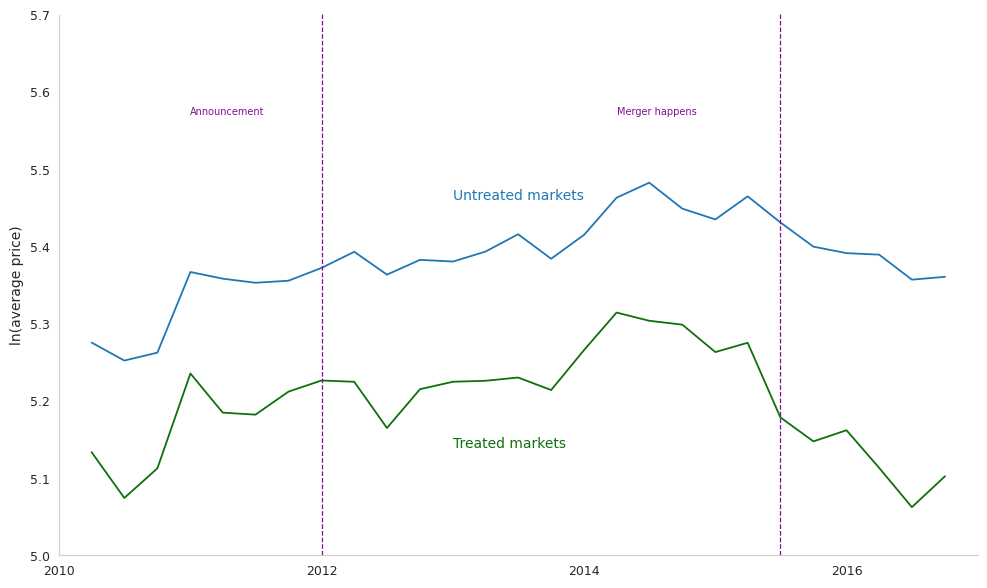

In [56]:
# Setup the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors
colors = ['#1F77B4', "#0E700B", "#880B9B"]  # blue, orange, green

# Plot treated and untreated markets
for i, treated_val in enumerate([False, True]):
        subset = data_agg[data_agg['treated'] == treated_val]
        ax.plot(subset['date'], subset['lnavgprice'], 
                        linewidth=1.3, 
                        color=colors[i], 
                        label='Treated markets' if treated_val else 'Untreated markets')

# Add vertical lines for announcement and merger
announcement_date = data_agg.loc[data_agg['quarters'] == '2012 Q1', 'date'].values[0]
merger_date = data_agg.loc[data_agg['quarters'] == '2015 Q3', 'date'].values[0]
ax.axvline(x=announcement_date, color=colors[2], linestyle='--', linewidth=0.9)
ax.axvline(x=merger_date, color=colors[2], linestyle='--', linewidth=0.9)

# Add text annotations
text_date = data_agg.loc[data_agg['quarters'] == '2013 Q1', 'date'].values[0]
ax.text(text_date, 5.14, 'Treated markets', color=colors[1], fontsize=10)
ax.text(text_date, 5.46, 'Untreated markets', color=colors[0], fontsize=10)

ax.text(data_agg.loc[data_agg['quarters'] == '2011 Q1', 'date'].values[0], 
                5.57, 'Announcement', color=colors[2], fontsize=7)
ax.text(data_agg.loc[data_agg['quarters'] == '2014 Q2', 'date'].values[0], 
                5.57, 'Merger happens', color=colors[2], fontsize=7)

# Set axis limits and formatting
ax.set_xlim(dt.strptime("2010-01-01", "%Y-%m-%d"), dt.strptime("2017-01-01", "%Y-%m-%d"))
ax.set_ylim(5, 5.6)
ax.set_yticks(np.arange(5.0, 5.7, 0.1))
ax.set_yticklabels([f'{y:.1f}' for y in np.arange(5.0, 5.7, 0.1)])

# Format x-axis dates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Add labels and styling
ax.set_ylabel('ln(average price)')
ax.grid(False)
plt.tight_layout()

# Apply clean theme
sns.set_style("whitegrid", {'axes.grid': False})
ax.tick_params(axis='both', which='major', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


In [146]:
data.columns

Index(['origin', 'finaldest', 'return', 'year', 'quarter', 'airports',
       'return_sym', 'stops', 'avgprice', 'passengers', 'itinfare',
       'sharelargest', 'share16', 'share9E', 'share9L', 'shareAA', 'shareAS',
       'shareB6', 'shareCO', 'shareCP', 'shareCS', 'shareDL', 'shareEV',
       'shareF8', 'shareF9', 'shareFL', 'shareG4', 'shareG7', 'shareHA',
       'shareL3', 'shareMQ', 'shareNK', 'shareOH', 'shareOO', 'shareOW',
       'shareQX', 'shareRP', 'shareS5', 'shareSY', 'shareU5', 'shareUA',
       'shareUS', 'shareVX', 'shareWN', 'shareXE', 'shareXJ', 'shareYV',
       'shareYX', 'shareZW', 'treated', 'smallmkt'],
      dtype='object')

In [156]:
data_agg.columns

Index(['treated', 'year', 'quarter', 'avgprice', 'lnavgprice', 'quarters',
       'date'],
      dtype='object')

In [161]:
# Create a pivot table with treated as columns, year and quarter as rows, and mean of lnavgprice
pivot_table = data_agg.pivot_table(
    values="lnavgprice",
    index=["year", "quarter"],
    columns="treated",
    aggfunc="mean"
)

# Rename columns for clarity
pivot_table.columns = ['Untreated', 'Treated']

# Display the result
pivot_table

Untreated   Treated
year quarter                     
2010 2         5.275344  5.133430
     3         5.252035  5.074198
     4         5.262291  5.112462
2011 1         5.366685  5.235314
     2         5.358039  5.184624
     3         5.352752  5.182054
     4         5.355393  5.211827
2012 1         5.372011  5.226265
     2         5.392850  5.224561
     3         5.363287  5.164739
     4         5.382411  5.214998
2013 1         5.380241  5.224638
     2         5.393055  5.225865
     3         5.415564  5.230084
     4         5.383836  5.213881
2014 1         5.414946  5.265892
     2         5.462817  5.314153
     3         5.482302  5.303542
     4         5.448709  5.298541
2015 1         5.434741  5.263011
     2         5.464628  5.275086
     3         5.430840  5.178479
     4         5.399473  5.147429
2016 1         5.391115  5.161846
     2         5.389134  5.113063
     3         5.356774  5.062306
     4         5.360438  5.102244

In [ ]:
# Create a pivot table with treated as columns, year and quarter as rows, and mean of lnavgprice
pivot_table = data_agg.pivot_table(
    values="lnavgprice",
    index=["year", "quarter"],
    columns="treated",
    aggfunc="mean"
)

# Rename columns for clarity
pivot_table.columns = ['Untreated', 'Treated']

# Display the result
pivot_table

**Small markets**

In [57]:
# if passengers < 5000

data_agg = (
    data.query("smallmkt == 1")
    .groupby(["treated", "year", "quarter"])
    .agg(avgprice=("avgprice", weighted_avg))
    .reset_index()
)

data_agg["lnavgprice"] = np.log(data_agg["avgprice"])
data_agg["quarters"] = (
    data_agg["year"].astype(str) + " Q" + data_agg["quarter"].astype(str)
)
# Create proper datetime by constructing a string in the format YYYYQN
data_agg["date"] = pd.to_datetime(
    data_agg["year"].astype(str) + "Q" + data_agg["quarter"].astype(str)
)


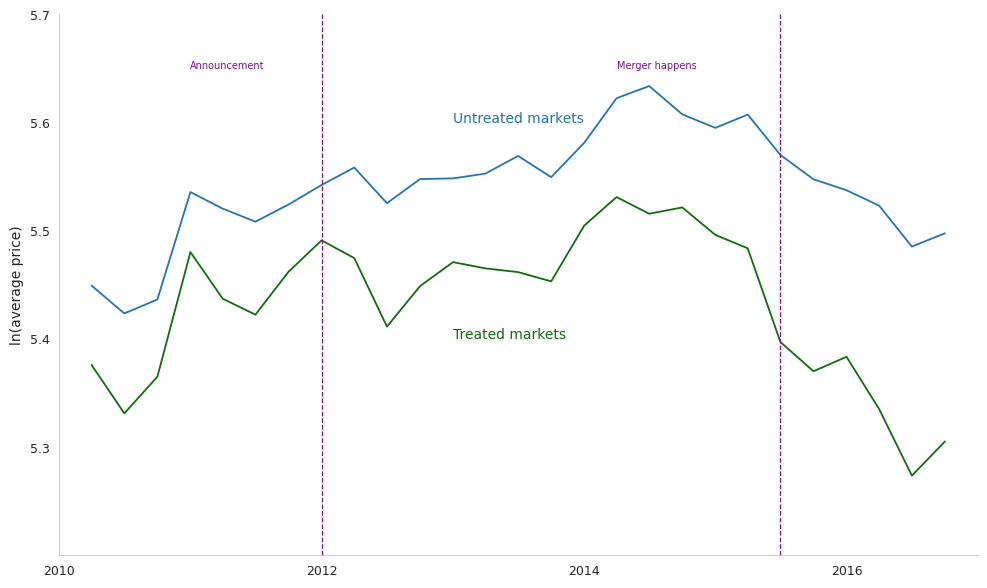

In [58]:
# Setup the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors
colors = ['#1F77B4', "#0E700B", "#880B9B"]  # blue, green, purple

# Plot treated and untreated markets
for i, treated_val in enumerate([False, True]):
    subset = data_agg[data_agg['treated'] == treated_val]
    ax.plot(subset['date'], subset['lnavgprice'], 
            linewidth=1.3, 
            color=colors[i], 
            label='Treated markets' if treated_val else 'Untreated markets')

# Add vertical lines for announcement and merger
announcement_date = data_agg.loc[data_agg['quarters'] == '2012 Q1', 'date'].values[0]
merger_date = data_agg.loc[data_agg['quarters'] == '2015 Q3', 'date'].values[0]
ax.axvline(x=announcement_date, color=colors[2], linestyle='--', linewidth=0.9)
ax.axvline(x=merger_date, color=colors[2], linestyle='--', linewidth=0.9)

# Add text annotations
text_date = data_agg.loc[data_agg['quarters'] == '2013 Q1', 'date'].values[0]
ax.text(text_date, 5.4, 'Treated markets', color=colors[1], fontsize=10)
ax.text(text_date, 5.6, 'Untreated markets', color=colors[0], fontsize=10)

# Add annotation for vertical lines
ax.text(data_agg.loc[data_agg['quarters'] == '2011 Q1', 'date'].values[0], 
        5.65, 'Announcement', color=colors[2], fontsize=7)
ax.text(data_agg.loc[data_agg['quarters'] == '2014 Q2', 'date'].values[0], 
        5.65, 'Merger happens', color=colors[2], fontsize=7)

# Set axis limits and formatting
ax.set_xlim(dt.strptime("2010-01-01", "%Y-%m-%d"), dt.strptime("2017-01-01", "%Y-%m-%d"))
ax.set_ylim(5.2, 5.7)
ax.set_yticks(np.arange(5.3, 5.7, 0.1))
ax.set_yticklabels([f'{y:.1f}' for y in np.arange(5.3, 5.7, 0.1)])

# Format x-axis dates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Add labels and styling
ax.set_ylabel('ln(average price)')
ax.grid(False)
plt.tight_layout()

# Apply clean theme
sns.set_style("whitegrid", {'axes.grid': False})
ax.tick_params(axis='both', which='major', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


**Large markets**

In [59]:
data_agg = (
    data.query("smallmkt == 0")
    .groupby(["treated", "year", "quarter"])
    .agg(avgprice=("avgprice", weighted_avg))
    .reset_index()
)

data_agg["lnavgprice"] = np.log(data_agg["avgprice"])
data_agg["quarters"] = (
    data_agg["year"].astype(str) + " Q" + data_agg["quarter"].astype(str)
)
# Create date values for plotting - convert year and quarter to proper datetime
data_agg["date"] = pd.to_datetime(
    data_agg["year"].astype(str) + "Q" + data_agg["quarter"].astype(str)
)


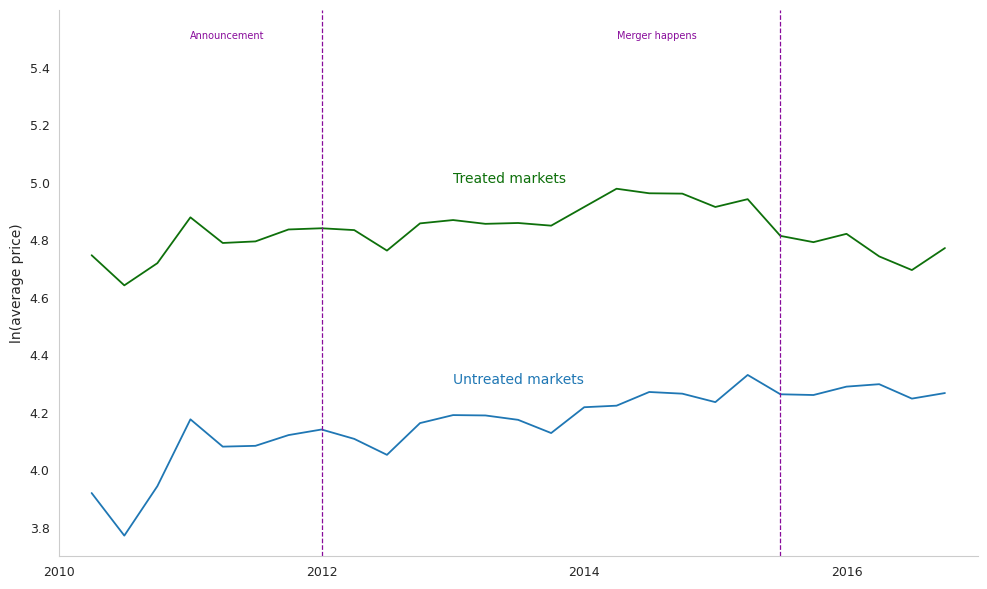

In [60]:
# Setup the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors
colors = ['#1F77B4', "#0E700B", "#880B9B"]  # blue, green, purple

# Plot treated and untreated markets
for i, treated_val in enumerate([False, True]):
    subset = data_agg[data_agg['treated'] == treated_val]
    ax.plot(subset['date'], subset['lnavgprice'], 
            linewidth=1.3, 
            color=colors[i], 
            label='Treated markets' if treated_val else 'Untreated markets')

# Add vertical lines for announcement and merger
announcement_date = data_agg.loc[data_agg['quarters'] == '2012 Q1', 'date'].values[0]
merger_date = data_agg.loc[data_agg['quarters'] == '2015 Q3', 'date'].values[0]
ax.axvline(x=announcement_date, color=colors[2], linestyle='--', linewidth=0.9)
ax.axvline(x=merger_date, color=colors[2], linestyle='--', linewidth=0.9)

# Add text annotations
text_date = data_agg.loc[data_agg['quarters'] == '2013 Q1', 'date'].values[0]
ax.text(text_date, 5.0, 'Treated markets', color=colors[1], fontsize=10)
ax.text(text_date, 4.3, 'Untreated markets', color=colors[0], fontsize=10)

# Add annotation for vertical lines
ax.text(data_agg.loc[data_agg['quarters'] == '2011 Q1', 'date'].values[0], 
        5.5, 'Announcement', color=colors[2], fontsize=7)
ax.text(data_agg.loc[data_agg['quarters'] == '2014 Q2', 'date'].values[0], 
        5.5, 'Merger happens', color=colors[2], fontsize=7)

# Set axis limits and formatting
ax.set_xlim(dt.strptime("2010-01-01", "%Y-%m-%d"), dt.strptime("2017-01-01", "%Y-%m-%d"))
ax.set_ylim(3.7, 5.6)

# Create evenly spaced ticks without gaps
y_ticks = np.arange(3.8, 5.6, 0.2)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{y:.1f}' for y in y_ticks])

# Format x-axis dates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Add labels and styling
ax.set_ylabel('ln(average price)')
ax.grid(False)
plt.tight_layout()

# Apply clean theme
sns.set_style("whitegrid", {'axes.grid': False})
ax.tick_params(axis='both', which='major', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# II. ANALYSIS
**Basic diff-in-diffs regression, weighted by # passengers on market, in before period**

In [61]:
# reload main file
data_agg = pd.read_pickle("/workspaces/codespaces-jupyter/data/ch22-airline-workfile.pkl")
data_agg


,origin,finaldest,return,year,airports,return_sym,stops,ptotalAA,ptotalUS,ptotallargest,...,pass_bef_id,pass_aft_id,pass_bef,pass_aft,balanced,treated,untreated,smallmkt,lnavgp,d_lnavgp
0,ABE,ABE,1,2011,9,0.0,3,0.0,0.0,1.0,...,1.0,NaN,1.0,NaN,False,NaN,NaN,NaN,5.117994,NaN
1,ABE,ABI,0,2011,4,NaN,2,0.0,0.0,1.0,...,1.0,NaN,1.0,NaN,False,NaN,NaN,NaN,6.834109,NaN
2,ABE,ABI,1,2011,7,1.0,2,0.0,0.0,2.0,...,2.0,NaN,2.0,5.0,True,False,True,True,6.604621,NaN
3,ABE,ABI,1,2016,7,1.0,2,3.0,0.0,4.0,...,NaN,5.0,2.0,5.0,True,False,True,True,6.604215,-0.000406
4,ABE,ABQ,0,2011,3,NaN,1,0.0,0.0,13.0,...,23.0,NaN,23.0,11.0,True,False,True,True,5.818663,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277605,YUM,XNA,1,2016,7,1.0,2,0.0,0.0,5.0,...,NaN,5.0,5.0,5.0,True,False,True,True,6.451102,0.523110
277606,YUM,YKM,0,2011,4,NaN,2,0.0,0.0,2.0,...,2.0,NaN,2.0,2.0,True,False,True,True,5.547129,NaN
277607,YUM,YKM,0,2016,4,NaN,2,0.0,0.0,2.0,...,NaN,2.0,2.0,2.0,True,False,True,True,5.339939,-0.207190
277608,YUM,YKM,1,2011,7,1.0,2,0.0,0.0,2.0,...,2.0,NaN,2.0,2.0,True,False,True,True,6.271933,NaN


In [62]:
# keep balanced
data_balanced = data_agg.query("balanced == 1")

In [63]:
fd = smf.wls("d_lnavgp ~ treated", data_balanced, weights=data_balanced["pass_bef"]).fit(cov_type="HC0")


# for small markets
fd_small = smf.wls("d_lnavgp ~ treated",data_balanced.query("smallmkt == 1"),weights=data_balanced.query("smallmkt == 1")["pass_bef"],
).fit(cov_type="HC0")


#for large markets
fd_large = smf.wls("d_lnavgp ~ treated",data_balanced.query("smallmkt == 0"),weights=data_balanced.query("smallmkt == 0")["pass_bef"],
).fit(cov_type="HC0")


In [71]:
fd.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:               d_lnavgp   R-squared:                       0.053
Model:                            WLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     325.6
Date:                Wed, 03 Sep 2025   Prob (F-statistic):           1.10e-72
Time:                        02:09:55   Log-Likelihood:            -1.9316e+05
No. Observations:              112632   AIC:                         3.863e+05
Df Residuals:                  112630   BIC:                         3.864e+05
Df Model:                           1                                         
Covariance Type:                  HC0                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1565      0.007     23.311      0.000       0.143       0.170
treated[T.True]    -0.1795      0.010    -18.045      0.000      -0.199      -0.160
==============================================================================
Omnibus:                    43773.559   Durbin-Watson:                   1.537
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         18490714.482
Skew:                           0.505   Prob(JB):                         0.00
Kurtosis:                      65.762   Cond. No.                         2.94
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC0)
"""

In [87]:
stargazer = Stargazer([fd, fd_small, fd_large])
stargazer.rename_covariates({"Intercept": "Constant", "treated[T.True]": "American Airlines BEFORE"})
stargazer.custom_columns(["All markets", "Small markets", "Large markets"], [1, 1, 1])
HTML(stargazer.render_html())


In [ ]:
fd_constants = {
    "All Markets": fd.params['Intercept'],
    "Small Markets": fd_small.params['Intercept'],
    "Large Markets": fd_large.params['Intercept']
}

# Convert intercepts from log to percent price levels
fd_constants_percent = {
    model: (np.exp(constant) - 1) * 100
    for model, constant in fd_constants.items()
}


print("Interpretation of Intercepts (Constants):\n")
for model, percent in fd_constants_percent.items():
    print(f"In {model}, the average baseline price in the control group AFTER the merger is approximately {percent:.2f}% higher than the reference level (e.g., baseline of 0).")

Interpretation of Intercepts (Constants):

In All Markets, the average baseline price in the control group AFTER the merger is approximately 16.94% higher than the reference level (e.g., baseline of 0).
In Small Markets, the average baseline price in the control group AFTER the merger is approximately 14.58% higher than the reference level (e.g., baseline of 0).
In Large Markets, the average baseline price in the control group AFTER the merger is approximately 26.83% higher than the reference level (e.g., baseline of 0).


In [111]:
fd_slopes = {
    "All Markets": fd.params["treated[T.True]"],
    "Small Markets": fd_small.params["treated[T.True]"],
    "Large Markets": fd_large.params["treated[T.True]"]
}

# Step 2: Compute price differences
fd_interpretation = {}

for model in fd_constants:
    const = fd_constants[model]
    slope = fd_slopes[model]

    untreated_price = np.exp(const)
    treated_price = np.exp(const + slope)

    untreated_growth = untreated_price - 1
    treated_growth = treated_price - 1

    # Difference in growth
    less_growth = (untreated_growth - treated_growth) / untreated_growth * 100

    # Actual change in treated group
    treated_change_pct = (treated_price - 1) * 100

    fd_interpretation[model] = {
        "less_growth": less_growth,
        "treated_change": treated_change_pct
    }


print("Interpretation of Treatment Effects:\n")
for model, result in fd_interpretation.items():
    growth_gap = result["less_growth"]
    treated_change = result["treated_change"]

    direction = "increased" if treated_change > 0 else "dropped"
    print(f"In {model}, price in treated markets increased by {growth_gap:.2f}% less on average compared to untreated markets. IN treated markets, prices actually {direction} by approximately {abs(treated_change):.2f}%.")

Interpretation of Treatment Effects:

In All Markets, price in treated markets increased by 113.43% less on average compared to untreated markets. IN treated markets, prices actually dropped by approximately 2.27%.
In Small Markets, price in treated markets increased by 118.92% less on average compared to untreated markets. IN treated markets, prices actually dropped by approximately 2.76%.
In Large Markets, price in treated markets increased by 106.43% less on average compared to untreated markets. IN treated markets, prices actually dropped by approximately 1.72%.


In [72]:
# Corresponding diff-in-diffs table
weighted_avg = lambda x: np.average(
    x,
    weights=data_balanced.loc[data_balanced["lnavgp"].notnull()].loc[
        x.index, "pass_bef"
    ],
)
data_balanced.loc[data_balanced["lnavgp"].notnull()].groupby(["after", "treated"]).agg(
    avgprice=("lnavgp", weighted_avg), n=("lnavgp", "count")
)


avgprice       n
after treated                  
0     False    4.926512  101275
      True     4.962715   11629
1     False    5.082928  101144
      True     4.939714   11628

In [86]:
# Compute the weighted average by group
diff_table = data_balanced.loc[
    data_balanced["lnavgp"].notnull()
].groupby(["after", "treated"]).agg(
    avgprice=("lnavgp", weighted_avg)
).reset_index()

# Pivot the table
pivot_table = diff_table.pivot(index="after", columns="treated", values="avgprice")

# Rename columns
pivot_table.columns = ["Untreated", "Treated"]
pivot_table.index = pivot_table.index.map({0: "Before", 1: "After"})

# Add Diff (Treated - Untreated)
pivot_table["Diff"] = pivot_table["Treated"] - pivot_table["Untreated"]

# Compute Diff-in-Diff
diff_in_diff = (
    pivot_table.loc["After", "Diff"] - pivot_table.loc["Before", "Diff"]
)

# Append as a new row
pivot_table.loc["Diff-in-Diff (After-Before)"] = [
    pivot_table.loc["After", "Untreated"] - pivot_table.loc["Before", "Untreated"],
    pivot_table.loc["After", "Treated"] - pivot_table.loc["Before", "Treated"],
    diff_in_diff
]

# Display
print(pivot_table)

                             Untreated   Treated      Diff
after                                                     
Before                        4.926512  4.962715  0.036202
After                         5.082928  4.939714 -0.143215
Diff-in-Diff (After-Before)   0.156416 -0.023001 -0.179417


**Diff-in-diffs regression with confounder variables weighted by # passengers on market, in before period**

In [113]:
data_balanced = data_balanced.merge(
    data_balanced.loc[lambda x: x["before"] == 1]
    .assign(
        lnpass=lambda x: np.log(x["passengers"]),
        sum_shares_bef=lambda x: x["shareAA"] + x["shareUS"],
    )
    .groupby("market")
    .agg(
        lnpass_bef=("lnpass", np.nanmean),
        share_bef=("sum_shares_bef", np.nanmean),
        sharelarge_bef=("sharelargest", np.nanmean),
    )
    .reset_index(),
    on="market",
)


In [114]:
data_balanced = data_balanced.rename(columns={"return": "return_"})

In [19]:
formula2 = "d_lnavgp ~ treated + lnpass_bef + return_ + stops + sharelarge_bef"

fd2 = smf.wls(formula2, data_balanced, weights=data_balanced["pass_bef"]).fit(
    cov_type="HC1"
)
fd2_small = smf.wls(
    formula2,
    data_balanced.query("smallmkt == 1"),
    weights=data_balanced.query("smallmkt == 1")["pass_bef"],
).fit(cov_type="HC0")
fd2_large = smf.wls(
    formula2,
    data_balanced.query("smallmkt == 0"),
    weights=data_balanced.query("smallmkt == 0")["pass_bef"],
).fit(cov_type="HC0")


In [20]:
stargazer = Stargazer([fd2, fd2_small, fd2_large])
stargazer.rename_covariates({"Intercept": "Constant"})
stargazer.custom_columns(["All markest", "Small markets", "Large markets"], [1, 1, 1])
HTML(stargazer.render_html())


**Diff-in-diffs regerssion with quantitative treatment weighted by # passengers on market, in before period**

In [21]:
share_bef_1 = np.where(data_balanced.query("before == 1")["share_bef"] == 1, 1, 0)
share_bef_0 = np.where(data_balanced.query("before == 1")["share_bef"] == 0, 1, 0)


In [22]:
data_balanced.query("before == 1").groupby([share_bef_0, share_bef_1]).agg(
    sum=("passengers", sum), mean=("passengers", "mean"), n=("passengers", "count")
)  # bit different from R


sum        mean      n
0 0  20169344  542.376207  37187
  1     34139    9.041049   3776
1 0   3746736   51.977360  72084

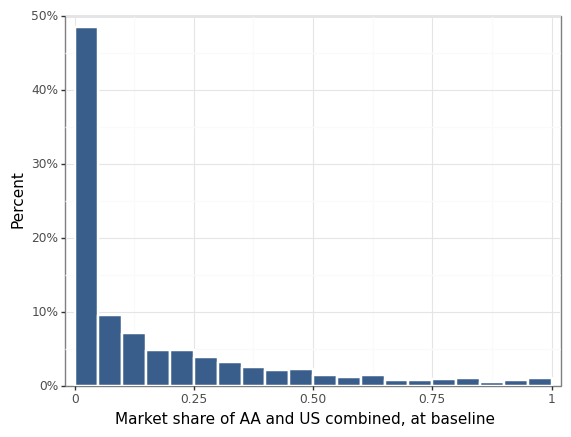

<ggplot: (679326474)>

In [23]:
(
    ggplot(
        data_balanced, aes(x="share_bef", y="stat(width*density)", weight="pass_bef")
    )
    + geom_histogram(
        binwidth=0.05,
        boundary=0,
        fill=color[0],
        alpha=0.8,
        colour="white",
        size=1,
        show_legend=False,
    )
    + labs(x="Market share of AA and US combined, at baseline", y="Percent")
    + scale_x_continuous(
        expand=(0.01, 0.01), limits=(0, 1), breaks=seq(0, 1, 0.25)
    )
    + scale_y_continuous(
        expand=(0.0, 0.0),
        limits=(0, 0.5),
        breaks=seq(0, 0.5, 0.1),
        labels=percent_format(),
    )
    + theme_bw()
)


In [24]:
formula3 = "d_lnavgp ~ share_bef + lnpass_bef + return_ + stops + sharelarge_bef"
fd3 = smf.wls(formula3, data_balanced, weights=data_balanced["pass_bef"]).fit(
    cov_type="HC0"
)
fd3_small = smf.wls(
    formula3,
    data_balanced.query("smallmkt == 1"),
    weights=data_balanced.query("smallmkt == 1")["pass_bef"],
).fit(cov_type="HC0")
fd3_large = smf.wls(
    formula3,
    data_balanced.query("smallmkt == 0"),
    weights=data_balanced.query("smallmkt == 0")["pass_bef"],
).fit(cov_type="HC0")


In [25]:
stargazer = Stargazer([fd3, fd3_small, fd3_large])
stargazer.rename_covariates({"Intercept": "Constant"})
stargazer.custom_columns(["All markest", "Small markets", "Large markets"], [1, 1, 1])
HTML(stargazer.render_html())


**Diff-in-diffs on pooled cross-sections regeression**
* use entire unbalanced panel
* errr... after only is dropped here see later
* weighted by # passengers on market, in before period

In [26]:
data_agg = data_agg.merge(
    data_agg.loc[lambda x: x["before"] == 1]
    .assign(lnpass_bef=lambda x: np.log(x["passengers"]))
    .groupby("market")
    .agg(
        lnpass_bef=("lnpass_bef", np.nanmean),
        sharelarge_bef=("sharelargest", np.nanmean),
    )
    .reset_index(),
    on="market",
    how="left",
)


In [27]:
data_agg.groupby(["balanced", "before"]).agg({"passengers": ["sum", "count"]})


passengers        
                       sum   count
balanced before                   
False    0          457978   22851
         1          103082   28665
True     0        30186202  113047
         1        23950219  113047

In [28]:
# treatment group defined if observed before only or both before and after


In [29]:
data_agg = data_agg.merge(
    data_agg.loc[lambda x: x["before"] == 1]
    .groupby("market")
    .agg(treatment=("AA_and_US", np.nanmean))
    .reset_index(),
    on="market",
)


In [30]:
data_agg["treatment_isna"] = data_agg["treatment"].isna()
data_agg.groupby(["treatment_isna", "balanced"]).agg({"passengers": ["sum", "count"]})


passengers        
                               sum   count
treatment_isna balanced                   
False          False        103082   28665
               True       54136421  226094

In [31]:
data_agg = data_agg.rename(columns={"return": "return_"})


In [32]:
# conditioning on observed confounders
formula4 = "lnavgp ~ (treatment + lnpass_bef + return_ + stops + sharelarge_bef)*after"

fd4 = smf.wls(formula4, data_agg, weights=data_agg["pass_bef"]).fit(cov_type="HC0")
fd4_small = smf.wls(
    formula4,
    data_agg.query("smallmkt == 1"),
    weights=data_agg.query("smallmkt == 1")["pass_bef"],
).fit(cov_type="HC0")
fd4_large = smf.wls(
    formula4,
    data_agg.query("smallmkt == 0"),
    weights=data_agg.query("smallmkt == 0")["pass_bef"],
).fit(cov_type="HC0")


In [33]:
stargazer = Stargazer([fd4, fd4_small, fd4_large])
stargazer.rename_covariates({"Intercept": "Constant"})
stargazer.custom_columns(["All markest", "Small markets", "Large markets"], [1, 1, 1])
HTML(stargazer.render_html())
